In [2]:
!pip install transitleastsquares

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

from transitleastsquares import transitleastsquares

In [5]:
load_path = "/content/drive/MyDrive/exoplanet_pipeline/data/stage1_output.pkl"

with open(load_path, "rb") as f:
    stage1_data = pickle.load(f)

print(stage1_data.keys())

dict_keys(['time', 'flux', 'flux_err', 'tic_id', 'crowdsap', 'ra', 'dec'])


In [6]:
time = stage1_data["time"]
flux = stage1_data["flux"]
flux_err = stage1_data["flux_err"]

tic_id = stage1_data["tic_id"]
crowdsap = stage1_data["crowdsap"]

ra = stage1_data["ra"]
dec = stage1_data["dec"]

print("TIC:", tic_id)
print("Cadences:", len(time))
print("CROWDSAP:", crowdsap)

TIC: 261136679
Cadences: 18261
CROWDSAP: 0.99965841


In [7]:
print(type(flux))
print(flux.dtype)

<class 'astropy.utils.masked.core.MaskedNDArray'>
float64


In [8]:
time = np.asarray(time)
flux = np.asarray(flux)
flux_err = np.asarray(flux_err)

In [9]:
print(time.min())
print(time.max())
print(np.isnan(flux).sum())

-2455674.703039505
-2455646.8229341027
0


In [10]:
time_tls = time - np.min(time)

print("Min:", time_tls.min())
print("Max:", time_tls.max())

Min: 0.0
Max: 27.880105402320623


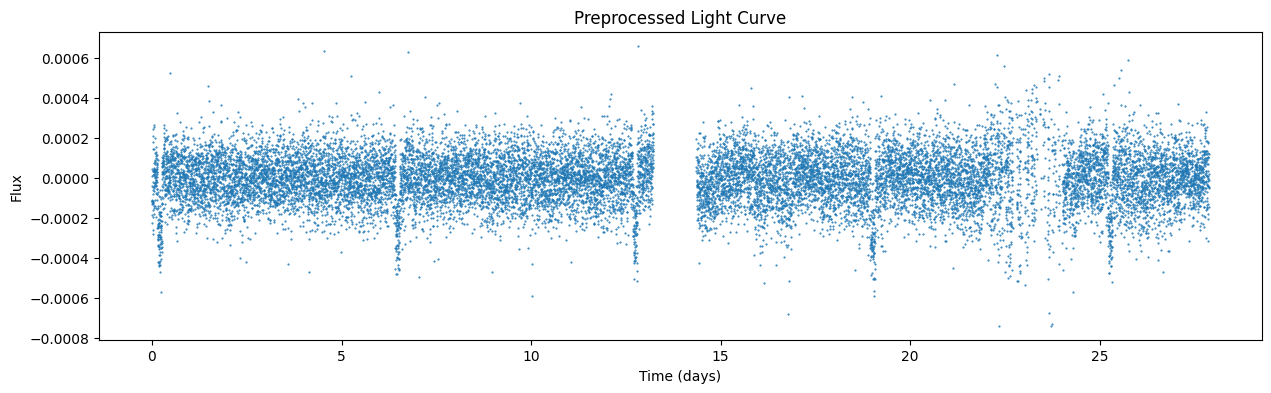

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))
plt.plot(time_tls, flux, ".", markersize=1)

plt.xlabel("Time (days)")
plt.ylabel("Flux")
plt.title("Preprocessed Light Curve")

plt.show()

In [12]:
from transitleastsquares import transitleastsquares

model = transitleastsquares(
    time_tls,
    flux
)

/usr/local/lib/python3.12/dist-packages/transitleastsquares/validate.py:31: UserWarning: Warning: The mean flux should be normalized to 1, but it was found to be 9.666567277014184e-05
  warnings.warn(text)


In [13]:
results = model.power()

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 9124 data points, 2552 periods from 0.601 to 13.933 days
Using all 2 CPU threads


100%|██████████| 2552/2552 periods | 00:31<00:00
/usr/local/lib/python3.12/dist-packages/transitleastsquares/main.py:205: UserWarning: No transit were fit. Try smaller "transit_depth_min"
  warnings.warn('No transit were fit. Try smaller "transit_depth_min"')


In [14]:
print("Period   :", results.period)
print("SDE      :", results.SDE)
print("Depth    :", results.depth)
print("Duration :", results.duration)
print("T0       :", results.T0)

Period   : nan
SDE      : 0
Depth    : 1
Duration : nan
T0       : 0


In [16]:
flux_tls = flux + 1
model = transitleastsquares(
    time_tls,
    flux_tls
)

results = model.power()

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 18260 data points, 2553 periods from 0.602 to 13.939 days
Using all 2 CPU threads


100%|██████████| 2553/2553 periods | 00:28<00:00


Searching for best T0 for period 6.26709 days
6.267090136076321
17.69836307589983
0.9997072757998143


In [17]:
print(results.period)
print(results.SDE)
print(results.depth)

6.267090136076321
17.69836307589983
0.9997072757998143


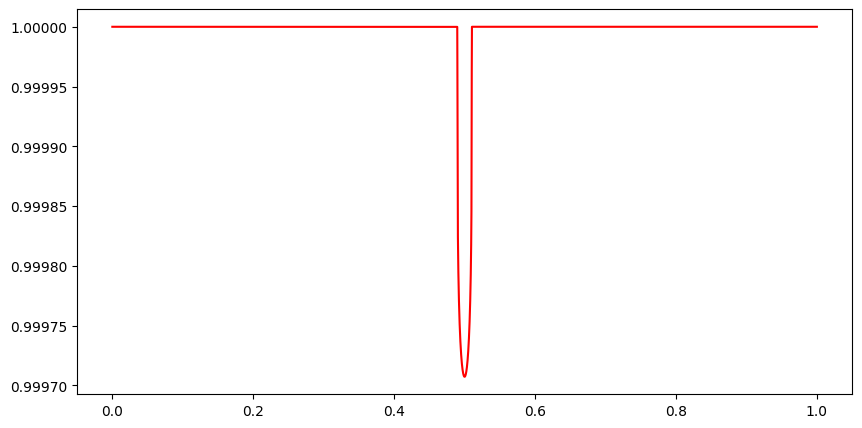

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(results.model_folded_phase,
         results.model_folded_model,
         color="red")

plt.show()

In [21]:
tls_features = {
    "period": float(results.period),
    "sde": float(results.SDE),
    "duration": float(results.duration),
    "t0": float(results.T0)
}

In [22]:
print("Period:", results.period)

print("Duration:", results.duration)

print("Depth:", results.depth)

print("T0:", results.T0)

print("Transit Count:", results.distinct_transit_count)

print("SNR:", results.snr)

print("Odd Even Mismatch:", results.odd_even_mismatch)

Period: 6.267090136076321
Duration: 0.12476139841324786
Depth: 0.9997072757998143
T0: 0.20952101445453392
Transit Count: 5
SNR: 41.52733356602065
Odd Even Mismatch: 2.5324346844809584
